# Facial Keypoint Detection and Emotion Recognition

This notebook demonstrates a complete deep learning project that focuses on two important areas of facial analysis: facial keypoint detection and facial emotion recognition. The project utilizes pre-trained Convolutional Neural Networks (CNNs) and various data augmentation techniques to build robust models capable of accurately performing these tasks.
The aim of the project is to classify the people's emotion based on the their face image.

Source: https://www.kaggle.com/c/facial-keypoints-detection/overview

Source: https://www.kaggle.com/c/challenges-in-representation-learning-facial-expression-recognition-challenge/data


# 1. Setup, Import Libraries and Utility Functions

This section handles the necessary library imports, Google Drive mounting for dataset access, and defines various utility functions and configurations used throughout the project.

In [1]:
# import packages
import os
import sys
import json
from pathlib import Path
from datetime import datetime
from typing import Tuple, Dict, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import copy
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from skimage.color import gray2rgb, rgb2gray
import pickle
from PIL import *
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.python.keras import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
from keras import optimizers
from google.colab.patches import cv2_imshow


In [2]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

#Project root folder path (update path accordingly based on project folder structure)
PROJECT_ROOT = Path("drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject")
print(os.listdir(PROJECT_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['data', 'output', 'Emotion_FacialKeypoints_Detection.ipynb']


In [3]:
# ============================================================
# Utilities used in the project execution
# ============================================================

# Changable parameter and hyperparameters
config = {
    'LEARNING_RATE': 1e-4,
    'BATCH_SIZE': 32,
    'EPOCHS': 40,
    'IMG_SIZE' : (96, 96),
    'SEED' : 42,
    'LOSS_FUNC' : 'categorical_crossentropy'
}

#All Facial emotions list directory (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral).
emotions_dict = {0:'Angry', 1:'Disgust', 2:'Fear', 3:'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# function to update config parameter value
def update_config(key, value):
    config[key] = value

# function to convert pixel values in string format to array format
def string2array(x):
  return np.array(x.split(' ')).reshape(48, 48, 1).astype('float32')

# Resize images from (48, 48) to (96, 96)
def resize(x):
  img = x.reshape(48, 48)
  return cv2.resize(img, dsize=(96, 96), interpolation = cv2.INTER_CUBIC)

# Function to set the seed value
def set_seed(seed: int) -> None:
    tf.keras.utils.set_random_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

# Function to create the runtime directories for executed files
def make_run_dir(root: Path, model_name: str) -> Path:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    d = root / f"{ts}_{model_name}"
    d.mkdir(parents=True, exist_ok=True)
    return d

# Function to display an image with its facial keypoints
def show_image_with_keypoints(img_id, keyfacial_ds):
    """
    Displays an image and overlays its facial keypoints.
    image: (96, 96) array
    keypoints: (30,) array of [x1, y1, x2, y2, ...]
    """
    i = img_id
    plt.imshow(keyfacial_ds['Image'][i], cmap = 'gray')
    for j in range(0, 30, 2):
      plt.plot(keyfacial_ds.loc[i].iloc[j], keyfacial_ds.loc[i].iloc[j+1], 'rX', fillstyle='none')

# Function to get the pre trained model keras application object for training the dataset based on the model name(input parameter)
def get_backbone(model_name: str) -> keras.Model:
    IMG_SIZE = config['IMG_SIZE']
    if model_name == "MobileNetV2":
        return keras.applications.MobileNetV2(
            include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)
        )
    if model_name == "ResNet152V2":
        return keras.applications.ResNet152V2(
            include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)
        )
    if model_name == "VGG16":
        return keras.applications.VGG16(
            include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)
        )
    if model_name == "DenseNet201":
        return keras.applications.DenseNet201(
            include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)
        )
    if model_name == "InceptionV3":
        return keras.applications.InceptionV3(
            include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)
        )
    if model_name == "ResNet50V2":
        return keras.applications.ResNet50V2(
            include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3)
        )
    raise ValueError(model_name)

# Function to build the custom model layers
def build_model(model_name: str, num_classes: int, actv: str) -> keras.Model:
    IMG_SIZE = config['IMG_SIZE']
    backbone = get_backbone(model_name)
    backbone.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    #x = layers.Dense(1024, activation='relu')(x) # Additional Dense layer
    #x = layers.BatchNormalization()(x)         # Batch Normalization
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation=actv)(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(config['LEARNING_RATE'], beta_1=0.9, beta_2=0.999),
        loss=config['LOSS_FUNC'],
        metrics=["accuracy"],
    )
    # save the best model with least validation loss
    return model

# Function to save the accuracy and Loss curve after completion of training each model
def save_training_curves(history: keras.callbacks.History, run_dir: Path) -> None:
    hist = history.history

    plt.figure()
    if "loss" in hist:
        plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(run_dir / "loss_curve.png", dpi=200)
    plt.close()

    plt.figure()
    if "accuracy" in hist:
        plt.plot(hist["accuracy"], label="train_acc")
    if "val_accuracy" in hist:
        plt.plot(hist["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(run_dir / "accuracy_curve.png", dpi=200)
    plt.close()

# Function to save the confusion matrix at output location
def save_confusion_matrix_image(cm: np.ndarray, run_dir: Path) -> None:
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Val)")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(run_dir / "confusion_matrix.png", dpi=250)
    plt.close()

# A function is defined to sequentially use both models, allowing for a qualitative assessment of the system's performance.
def predict(X_test):

  # Making prediction from the keypoint model
  df_predict = model_1_facialKeyPoints.predict(X_test)

  # Making prediction from the emotion model
  df_emotion = np.argmax(model_2_emotions.predict(X_test), axis=-1)

  # Reshaping array
  df_emotion = np.expand_dims(df_emotion, axis = 1)

  # Converting the predictions into a dataframe
  df_predict = pd.DataFrame(df_predict, columns= columns)

  # Adding emotion into the predicted dataframe
  df_predict['emotion'] = df_emotion

  return df_predict



# 2. Facial Keypoint Detection

This section focuses on the development of a deep learning model for facial keypoint detection. It covers data loading, exploration, augmentation strategies, data preprocessing, model training using a pre-trained CNN backbone, and evaluation of the trained model.

## 2.1 Data Loading and Exploration (Facial Keypoints)

Here, the facial keypoint dataset is loaded, and its structure and content are examined to understand the data's characteristics, including column information, data types, and the format of image pixel data.

In [46]:
# load facial keypoints dataset
keyfacial_csv_file_path = PROJECT_ROOT / "data/facial_keypoint_data.csv"
keyfacial_ds = pd.read_csv(keyfacial_csv_file_path)
keyfacial_ds.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [47]:
# Obtain relevent information about the dataset
# Keyfacial points co-ordinates : total 15
# x-coordinated are in even columns, y-coordinates are in odd columns
# Image pixcel information as an object is in last column
keyfacial_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [48]:
# Check if any null value is exist in the data for data cleaning
keyfacial_ds.isnull().sum()

,0
left_eye_center_x,0
left_eye_center_y,0
right_eye_center_x,0
right_eye_center_y,0
left_eye_inner_corner_x,0
left_eye_inner_corner_y,0
left_eye_outer_corner_x,0
left_eye_outer_corner_y,0
right_eye_inner_corner_x,0
right_eye_inner_corner_y,0


In [49]:
# Image is an object in data file and shape of Image object
keyfacial_ds['Image'].shape

(2140,)

In [50]:
# Image columnin dataset: each image (in each row) it contains a long string of numbers,
# where each number represents the intensity of a pixel in the image.
keyfacial_ds['Image'][0]

'238 236 237 238 240 240 239 241 241 243 240 239 231 212 190 173 148 122 104 92 79 73 74 73 73 74 81 74 60 64 75 86 93 102 100 105 109 114 121 127 132 134 137 137 140 139 138 137 137 140 141 143 144 147 148 149 147 147 148 145 147 144 146 147 147 143 134 130 130 128 116 104 98 90 82 78 85 88 86 80 77 87 108 111 115 128 133 188 242 252 250 248 251 250 250 250 235 238 236 238 238 237 238 242 241 239 237 233 215 195 187 156 119 103 93 78 68 73 75 75 72 75 70 61 66 77 91 96 106 108 113 120 125 131 134 138 135 138 139 145 144 144 142 140 141 141 148 147 150 149 152 151 149 150 147 148 144 148 144 146 146 143 139 128 132 135 128 112 104 97 87 78 79 83 85 83 75 75 89 109 111 117 117 130 194 243 251 249 250 249 250 251 237 236 237 238 237 238 241 238 238 238 241 221 195 187 163 124 106 95 81 68 70 73 73 72 73 69 65 74 82 94 103 110 111 119 127 135 140 139 144 144 145 143 143 143 146 144 144 147 146 148 147 150 146 147 150 150 149 147 147 144 147 144 149 146 144 144 144 140 131 133 133 125 110 

In [51]:
# since value for the image is given as space seperate string,
# seperate the values using ' ' as seperator.
# Then covert this into numpy array and then convert it again from 1D array into 2D array of shape (96, 96)
# each image is a vector of 96*96 pixels (96*96 = 9216)
keyfacial_ds['Image'] = keyfacial_ds['Image'].apply(lambda x: np.fromstring(x, dtype = int, sep = ' ').reshape(96, 96) )

In [52]:
# Get the shape of image
keyfacial_ds['Image'][0].shape

(96, 96)

## 2.2 Image Visualization (Facial keypoints)

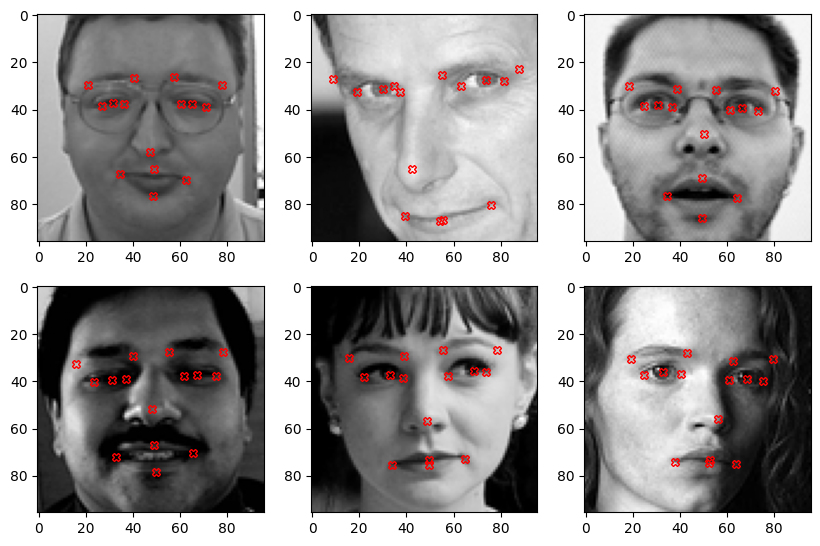

In [53]:
# Plot a random images from the dataset along with facial keypoints
fig = plt.figure(figsize=(10, 10))

for i in range(6):
  ax = fig.add_subplot(3, 3, i + 1)
  k = np.random.randint(1, len(keyfacial_ds))
  show_image_with_keypoints(k, keyfacial_ds)

## 2.3 Data Augmentation (Facial Keypoints)

To improve the model's generalization capabilities and robustness to variations in facial orientation, data augmentation techniques such as horizontal flipping and brightness adjustment are applied to the keypoint dataset. Special care is taken to ensure that keypoint coordinates are adjusted correctly with respect to image transformations.

In [54]:
# create a new copy of datset
keyfacial_ds_copy = copy.copy( keyfacial_ds)

# obtaing columns of the dataset
columns = keyfacial_ds_copy.columns[:-1]
columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y'],
      dtype='object')

In [55]:
# Horizontal flip:- flip the image along the y-axis
keyfacial_ds_copy['Image'] = keyfacial_ds_copy['Image'].apply(lambda x: np.flip(x, axis = 1))

# As fliped horizontally, all the y-cordinates (odd columns) value remain same
# Only change x-cordinates (even columns) values: [Width of image(96) - initial x-xordinate value]
for i in range(len(columns)):
  if i % 2 == 0:
    keyfacial_ds_copy[columns[i]] = keyfacial_ds_copy[columns[i]].apply(lambda x: 96 - x)

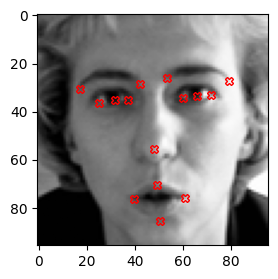

In [56]:
# Display horizontally fliped image and verify the keyfacial points with original Images
fig = plt.figure(figsize=(3, 3))
show_image_with_keypoints(1, keyfacial_ds_copy)

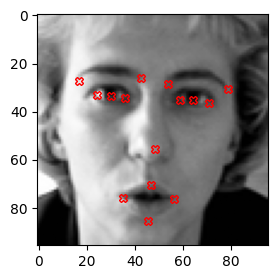

In [57]:
# Display original image and verify the keyfacial points with original Images
fig = plt.figure(figsize=(3, 3))
show_image_with_keypoints(1, keyfacial_ds)

In [58]:
# Concatenate the original dataset with augmented dataset
augmented_ds = np.concatenate((keyfacial_ds, keyfacial_ds_copy))

In [59]:
# Verify the augmented_ds shape increase from 2140 entries to 4280
augmented_ds.shape

(4280, 31)

In [60]:
# Vertical flip:- flip the image along the x-axis
keyfacial_ds_copy = copy.copy(keyfacial_ds)
columns = keyfacial_ds_copy.columns[:-1]
keyfacial_ds_copy['Image'] = keyfacial_ds_copy['Image'].apply(lambda x: np.flip(x, axis = 0))
for i in range(len(columns)):
  if i%2 == 1:
    keyfacial_ds_copy[columns[i]] = keyfacial_ds_copy[columns[i]].apply(lambda x: 96. - float(x) )
keyfacial_ds_copy.shape

(2140, 31)

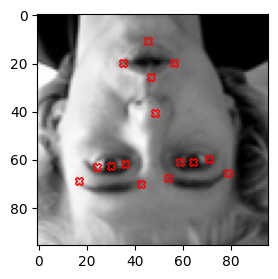

In [61]:
# Display vertically fliped image and verify the keyfacial points with original Images
fig = plt.figure(figsize=(3, 3))
show_image_with_keypoints(1, keyfacial_ds_copy)

In [62]:
# Randomly increase the brightness of images
#
keyfacial_ds_copy = copy.copy(keyfacial_ds)
keyfacial_ds_copy['Image'] = keyfacial_ds_copy['Image'].apply(lambda x: np.clip(random.uniform(1.5, 2)* x, 0.0, 255.0))


In [63]:
# Copy updated augmented data into the dataset
augmented_ds = np.concatenate((augmented_ds, keyfacial_ds_copy))
augmented_ds.shape

(6420, 31)

In [64]:
# Convert the 'Image' column (which contains numpy arrays) to string representation
augmented_ds_for_save = augmented_ds.copy()

# Assuming the last column is the 'Image' column with numpy arrays
augmented_ds_for_save[:, -1] = [np.array2string(arr, separator=' ', max_line_width=np.inf) for arr in augmented_ds_for_save[:, -1]]

# Convert the numpy array to a pandas DataFrame
columns_list = keyfacial_ds.columns.tolist()
augmented_df = pd.DataFrame(augmented_ds_for_save, columns=columns_list)

# Define the output path
output_dir = PROJECT_ROOT / "data"
output_dir.mkdir(parents=True, exist_ok=True)
output_file_path = output_dir / "augmented_facialkeypoint_dataset.csv"

# Save the DataFrame to a CSV file
augmented_df.to_csv(output_file_path, index=False)

print(f"Augmented dataset saved to: {output_file_path}")

Augmented dataset saved to: drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/data/augmented_facialkeypoint_dataset.csv


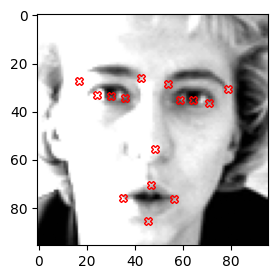

In [65]:
# Display vertically fliped image and verify the keyfacial points with original Images
fig = plt.figure(figsize=(3, 3))
show_image_with_keypoints(1, keyfacial_ds_copy)

## 2.4 Data Preparation for Model (Facial Keypoints)

The augmented keypoint data is prepared for input into the neural network. This involves extracting image pixel data and keypoint coordinates, reshaping images to the required input format.

In [66]:
#augm_kf_csv_file_path = PROJECT_ROOT / "data/augmented_facialkeypoint_dataset.csv"
#keyfacial_ds_copy = pd.read_csv(augm_kf_csv_file_path)
keyfacial_ds_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [78]:
# Obtain the value of images which is present in the 31st column (since index start from 0, we refer to 31st column by 30)
img = augmented_ds[:,30]

# Reshape the image size to 96X96
X = np.stack(img, axis = 0)
X = X.reshape(len(img), 96, 96)

# As images are gray scale , to execute it using pretrained "imagenet" weights changing the grayscale(1 channel) to RGB(3 channel) input
rgb_kp_X = gray2rgb(X)

# Extract the first 30 columns (indices 0 to 29) as labels
kp_y = np.asarray(augmented_ds[:, :30]).astype(np.float32)

print(rgb_kp_X.shape, kp_y.shape)

(6420, 96, 96, 3) (6420, 30)


## 2.5 Keypoint Detection Model Training

This sub-section details the configuration and training process for the facial keypoint detection model. A pre-trained model backbone is used, followed by custom layers, and the model is trained using Huber loss with callbacks for early stopping, learning rate reduction, and model checkpointing. A accuracy graph and Loss graph also saved into directory to check the performance of the model for reference.

In [68]:
# ============================================================
# Configuration parameters
# ============================================================

OUTPUT_ROOT = PROJECT_ROOT / "output" / "train_runs" / "keyfacial"

IMG_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
SEED = 42
LOSS_FUNC = 'huber' # 'huber' or 'mean_squared_error'

update_config('LOSS_FUNC', LOSS_FUNC)
update_config('LEARNING_RATE', LEARNING_RATE)

MODEL_NAME = "MobileNetV2"  # change ONE LINE to compare models
# Options: "MobileNetV2", "ResNet152V2", "VGG16", "DenseNet201", "InceptionV3", "ResNet50V2"

# Early stopping (standard practice)
EARLY_STOP_PATIENCE = 3

# ============================================================
# Main flow
# ============================================================

set_seed(SEED)

run_dir = make_run_dir(OUTPUT_ROOT, MODEL_NAME)

# split the dataframe in to train, test and validation data frames
#Split into temporary train (70%) and  test (15%) and validation (15%)

X_train, X_test, y_train, y_test = train_test_split(rgb_kp_X, kp_y, test_size = 0.3)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5)

# image pre-processing
X_train = X_train/255
X_val   = X_val /255
X_test  = X_test/255

# Build the model
model = build_model(MODEL_NAME, num_classes=30, actv="relu")

# Set the callback function
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(run_dir / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),
]

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=callbacks,)

# Save training curve figures (loss and accuracy)
save_training_curves(history, run_dir)

# Save the best trained model
model.save(run_dir / "final_model.keras")

print(f"[DONE] Training completed. Results saved to {run_dir}")


Epoch 1/30
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0089 - loss: 45.0042
Epoch 1: val_loss improved from None to 39.66336, saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs/keyfacial/20260414_182647_MobileNetV2/best_model.keras

Epoch 1: finished saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs/keyfacial/20260414_182647_MobileNetV2/best_model.keras
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.0087 - loss: 43.3281 - val_accuracy: 0.0021 - val_loss: 39.6634 - learning_rate: 1.0000e-04
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0111 - loss: 37.8112
Epoch 2: val_loss improved from 39.66336 to 32.50520, saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs/keyfacial/20260414_182647_MobileNetV2/best_model.keras

Epoch 2: finished saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs

## 2.6 Keypoint Detection Model Evaluation

After training, the keypoint detection model is evaluated on the unseen test dataset to assess its performance. Key metrics such as loss and accuracy are reported.

In [69]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │        38,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,276 (9.05 MB)

 Trainable params: 38,430 (150.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 76,862 (300.25 KB)

In [70]:
# Load the best entire model
model_1_facialKeyPoints = keras.models.load_model(run_dir / "final_model.keras")
#model_1_facialKeyPoints = keras.models.load_model(PROJECT_ROOT / "output/train_runs/keyfacial/20260414_143651_ResNet50V2/final_model.keras")

# evaluate test dataset
results_keyfacial = model_1_facialKeyPoints.evaluate(X_test, y_test)

# results is a list containing [loss, accuracy]
print(f"Test Loss: {results_keyfacial[0]}")
print(f"Test Accuracy: {results_keyfacial[1]}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.6750 - loss: 7.3155
Test Loss: 7.315469264984131
Test Accuracy: 0.6749740242958069


# 3. Facial Emotion DETECTION

This section outlines the development of a model for facial emotion recognition. Similar to keypoint detection, it covers data loading, exploration, specific augmentation strategies for emotion classification, data preparation, model training using a different pre-trained CNN backbone, and thorough evaluation with classification metrics.

This model detect the below facial emotions for given dataset:
 * (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral).

## 3.1 Data Loading and Exploration (Emotions)

The emotion dataset is loaded, and its characteristics are explored, including the distribution of emotion classes.

In [4]:
# read the csv files for the facial expression data
emotions_csv_file_path = PROJECT_ROOT / "data/icml_emotions_data.csv"
facialexpression_ds = pd.read_csv(emotions_csv_file_path)

In [5]:
facialexpression_ds.head()

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [6]:

facialexpression_ds[' pixels'] = facialexpression_ds[' pixels'].apply(lambda x: string2array(x))
facialexpression_ds[' pixels'] = facialexpression_ds[' pixels'].apply(lambda x: resize(x))
facialexpression_ds.head()

,emotion,pixels
0,0,"[[69.316925, 73.03865, 79.13719, 84.17186, 85...."
1,0,"[[151.09435, 150.91393, 150.65791, 148.96367, ..."
2,2,"[[232.82552, 229.81886, 225.59953, 200.68909, ..."
3,4,"[[23.061905, 25.50914, 29.47847, 33.99843, 36...."
4,6,"[[4.771652, 3.3384705, 0.9779358, -0.45524597,..."


In [7]:
# check the shape of data_frame
facialexpression_ds.shape

(35887, 2)

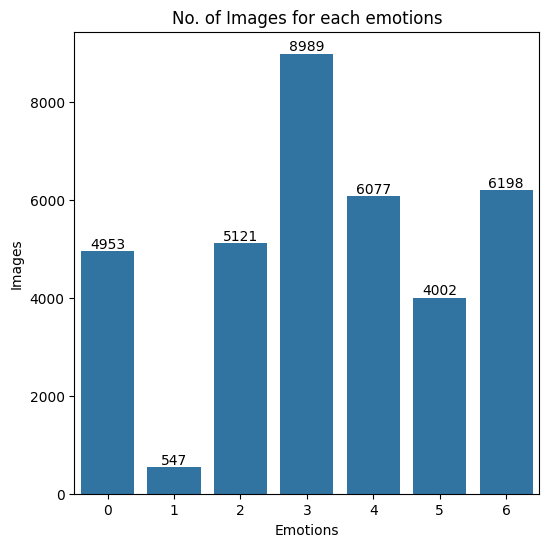

In [8]:
#  Plot bar chart to show number of images as per emotion
plt.figure(figsize = (6,6))
plt.title("No. of Images for each emotions")
plt.xlabel("Emotions")
plt.ylabel("Images")
ax = sns.barplot(x = facialexpression_ds.emotion.value_counts().index, y = facialexpression_ds.emotion.value_counts())
# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

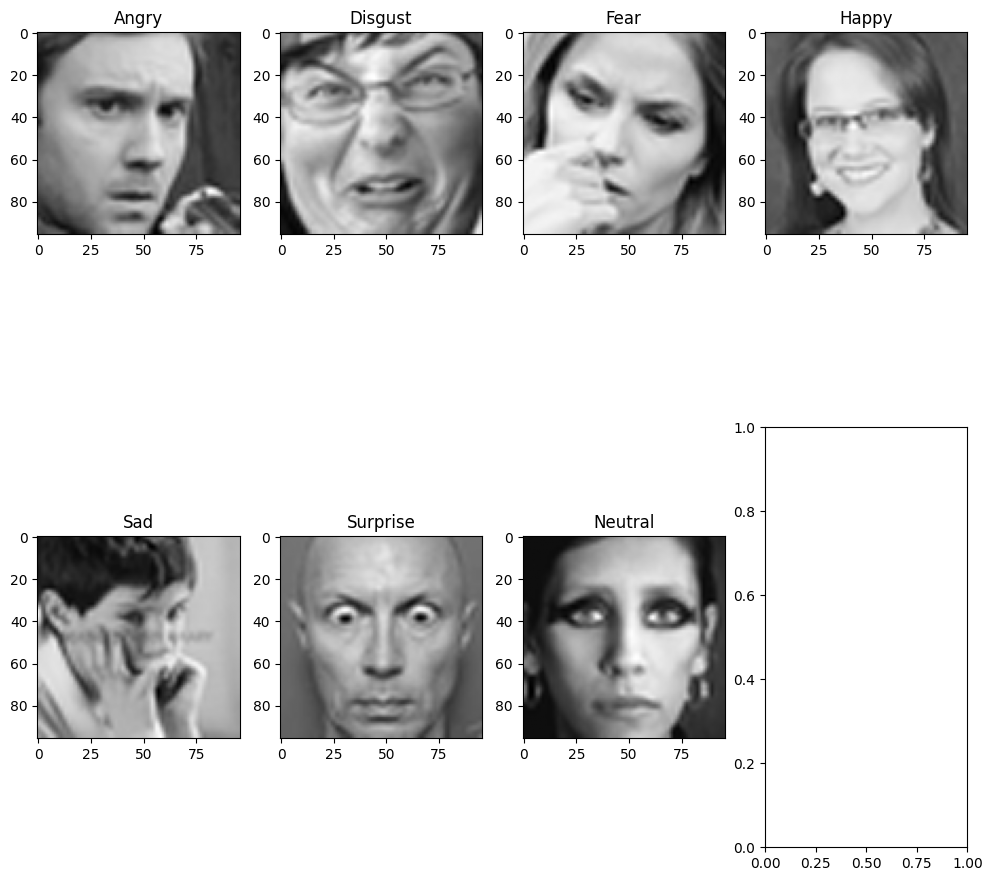

In [9]:
emotions = [0, 1, 2, 3, 4, 5, 6]
fig, axis = plt.subplots(2, 4, figsize = (12, 12))
axes = axis.ravel()

for j in range(6):
  for i in emotions:
    data = facialexpression_ds[facialexpression_ds['emotion'] == i][:1]
    img = data[' pixels'].item()
    img = img.reshape(96, 96)
    axes[i].set_title(emotions_dict.get(i))
    axes[i].imshow(img, cmap='gray')

## 3.2 Data Preparation (Emotions)

Raw pixel data is converted into image arrays, images are resized and normalized, and emotion labels are one-hot encoded.

In [10]:
# split the dataframe in to features and labels
from keras.utils import to_categorical

X = facialexpression_ds[' pixels']
em_y = to_categorical(facialexpression_ds['emotion'])

# Reshape the input date to 96X96 image size
X = np.stack(X, axis = 0)
X = X.reshape(len(X), 96, 96)

# update the grayscale(1 channel) image to RGB (3 channel)
rgb_em_X = gray2rgb(X)

print(rgb_em_X.shape, em_y.shape)



(35887, 96, 96, 3) (35887, 7)


## 3.3 Emotion Recognition Model Training

This sub-section describes the setup and training of the emotion recognition model. A pre-trained models("MobileNetV2", "ResNet152V2", "VGG16", "DenseNet201", "InceptionV3", "ResNet50V2") backbone is utilized, with a custom classification head. The model is trained using categorical cross-entropy loss, incorporating callbacks for early stopping, learning rate reduction, and model checkpointing. Also data augmentation (rotation, shifting, zooming, horizontal flipping) is applied during training using `ImageDataGenerator` to improve model robustness and address the variability in facial expressions.

Performance is assessed using standard classification metrics such as accuracy, and a detailed classification report including precision, recall, and F1-score for each emotion category is generated. A confusion matrix is also produced to visualize class-wise prediction accuracy.
A accuracy graph and Loss graph also saved into directory to check the performance of the model for reference.

In [ ]:
# ============================================================
# Configuration
# ============================================================

OUTPUT_ROOT = PROJECT_ROOT / "output" / "train_runs" / "emotions"

IMG_SIZE = (96, 96)
BATCH_SIZE = 64
EPOCHS = 25
LEARNING_RATE = 1e-4
SEED = 42

update_config('LOSS_FUNC', 'categorical_crossentropy')
update_config('LEARNING_RATE', LEARNING_RATE)

MODEL_NAME = "VGG16"  # change ONE LINE to compare models
# Options: "MobileNetV2", "ResNet152V2", "VGG16", "DenseNet201", "InceptionV3", "ResNet50V2"

# Early stopping (standard practice)
EARLY_STOP_PATIENCE = 3



# ============================================================
# Main flow
# ============================================================


set_seed(SEED)

run_dir = make_run_dir(OUTPUT_ROOT, MODEL_NAME)

# split the dataframe in to train, test and validation data frames
# Split into temporary train (70%) and  test (15%) and validation (15%)

X_Train, X_Test, y_Train, y_Test = train_test_split(rgb_em_X, em_y, test_size = 0.3, shuffle = True)
X_Val, X_Test, y_Val, y_Test = train_test_split(X_Test, y_Test, test_size = 0.5, shuffle = True)

# image pre-processing

X_Train = X_Train/255
X_Val   = X_Val /255
X_Test  = X_Test/255

# Data augmentation on the emotion dataset
datagen = ImageDataGenerator(
	  rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    shear_range = 0.1,
    zoom_range = 0.1,
    horizontal_flip = True,
    vertical_flip = False,
    fill_mode = "nearest")

train_datagen = datagen.flow(X_Train, y_Train, batch_size = BATCH_SIZE)

# Build the model
model = build_model(MODEL_NAME, num_classes=7, actv="softmax")

# set the callback function
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(run_dir / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=1,
        min_lr=1e-6,
        verbose=1
    ),

]
# Train the model
history = model.fit(train_datagen,
                    validation_data=(X_Val, y_Val),
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    callbacks=callbacks,)

# Save training curve figures (loss/accuracy)
save_training_curves(history, run_dir)

# save final model to the directory
model.save(run_dir / "final_model.keras")

# ============================================================
# Validation Evaluation & Confusion Matrix Generation
# ============================================================

y_true, y_pred = [], []
y_pred_probs = model.predict(X_Val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_Val, axis=1)

labels = list(emotions_dict.keys())
cm = confusion_matrix(y_true, y_pred, labels=labels)
np.save(run_dir / "confusion_matrix.npy", cm)

# Save confusion matrix as an image
save_confusion_matrix_image(cm, run_dir)

report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=list(emotions_dict.values()),
    digits=4,
    zero_division=0
)
(run_dir / "classification_report.txt").write_text(report)

# Print classification report for emotion dataset
print(report)

print(f"[DONE] Training completed. Results saved to {run_dir}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1629 - loss: 1.9996
Epoch 1: val_loss improved from None to 1.78755, saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs/emotions/20260414_205736_VGG16/best_model.keras

Epoch 1: finished saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs/emotions/20260414_205736_VGG16/best_model.keras
393/393 ━━━━━━━━━━━━━━━━━━━━ 826s 2s/step - accuracy: 0.1870 - loss: 1.9187 - val_accuracy: 0.2588 - val_loss: 1.7876 - learning_rate: 1.0000e-04
Epoch 2/25
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2340 - loss: 1.8217
Epoch 2: val_loss improved from 1.78755 to 1.74983, saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/output/train_runs/emotions/20260414_205736_VGG16/best_model.keras

Epoch 2: finished saving model to drive/MyDrive/UMD/CIS583_DeepLearning/DeepLearningProject/

## 3.4 Emotion Recognition Model Evaluation

The trained emotion recognition saved best model is evaluated on the test set.

In [ ]:
# Load the best entire model
model_2_emotions = keras.models.load_model(run_dir / "final_model.keras")
#model_2_emotions = keras.models.load_model(PROJECT_ROOT / "output/train_runs/emotions/20260413_194423_ResNet50V2/final_model.keras")

print(f"Model 2 emotions output shape: {model_2_emotions.output_shape}")

# evaluate test datasetaluate
result_emotions = model_2_emotions.evaluate(X_Test, y_Test)

# results is a list containing [loss, accuracy]
print(f"Test Loss: {result_emotions[0]}")
print(f"Test Accuracy: {result_emotions[1]}")

In [ ]:
model_2_emotions.summary()

# 4. Integrated Prediction and Visualization

This section demonstrates how the trained keypoint detection and emotion recognition models can be combined to provide an integrated facial analysis system. A `predict` function is defined to sequentially use both models. Visualizations show predicted keypoints and emotions overlaid on test images, allowing for a qualitative assessment of the system's performance.

In [14]:
y_true, y_pred = [], []

# predicted_classes for test dataset
y_pred = np.argmax(model_2_emotions.predict(X_Test), axis=-1)
y_true = np.argmax(y_Test, axis=-1)


169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step


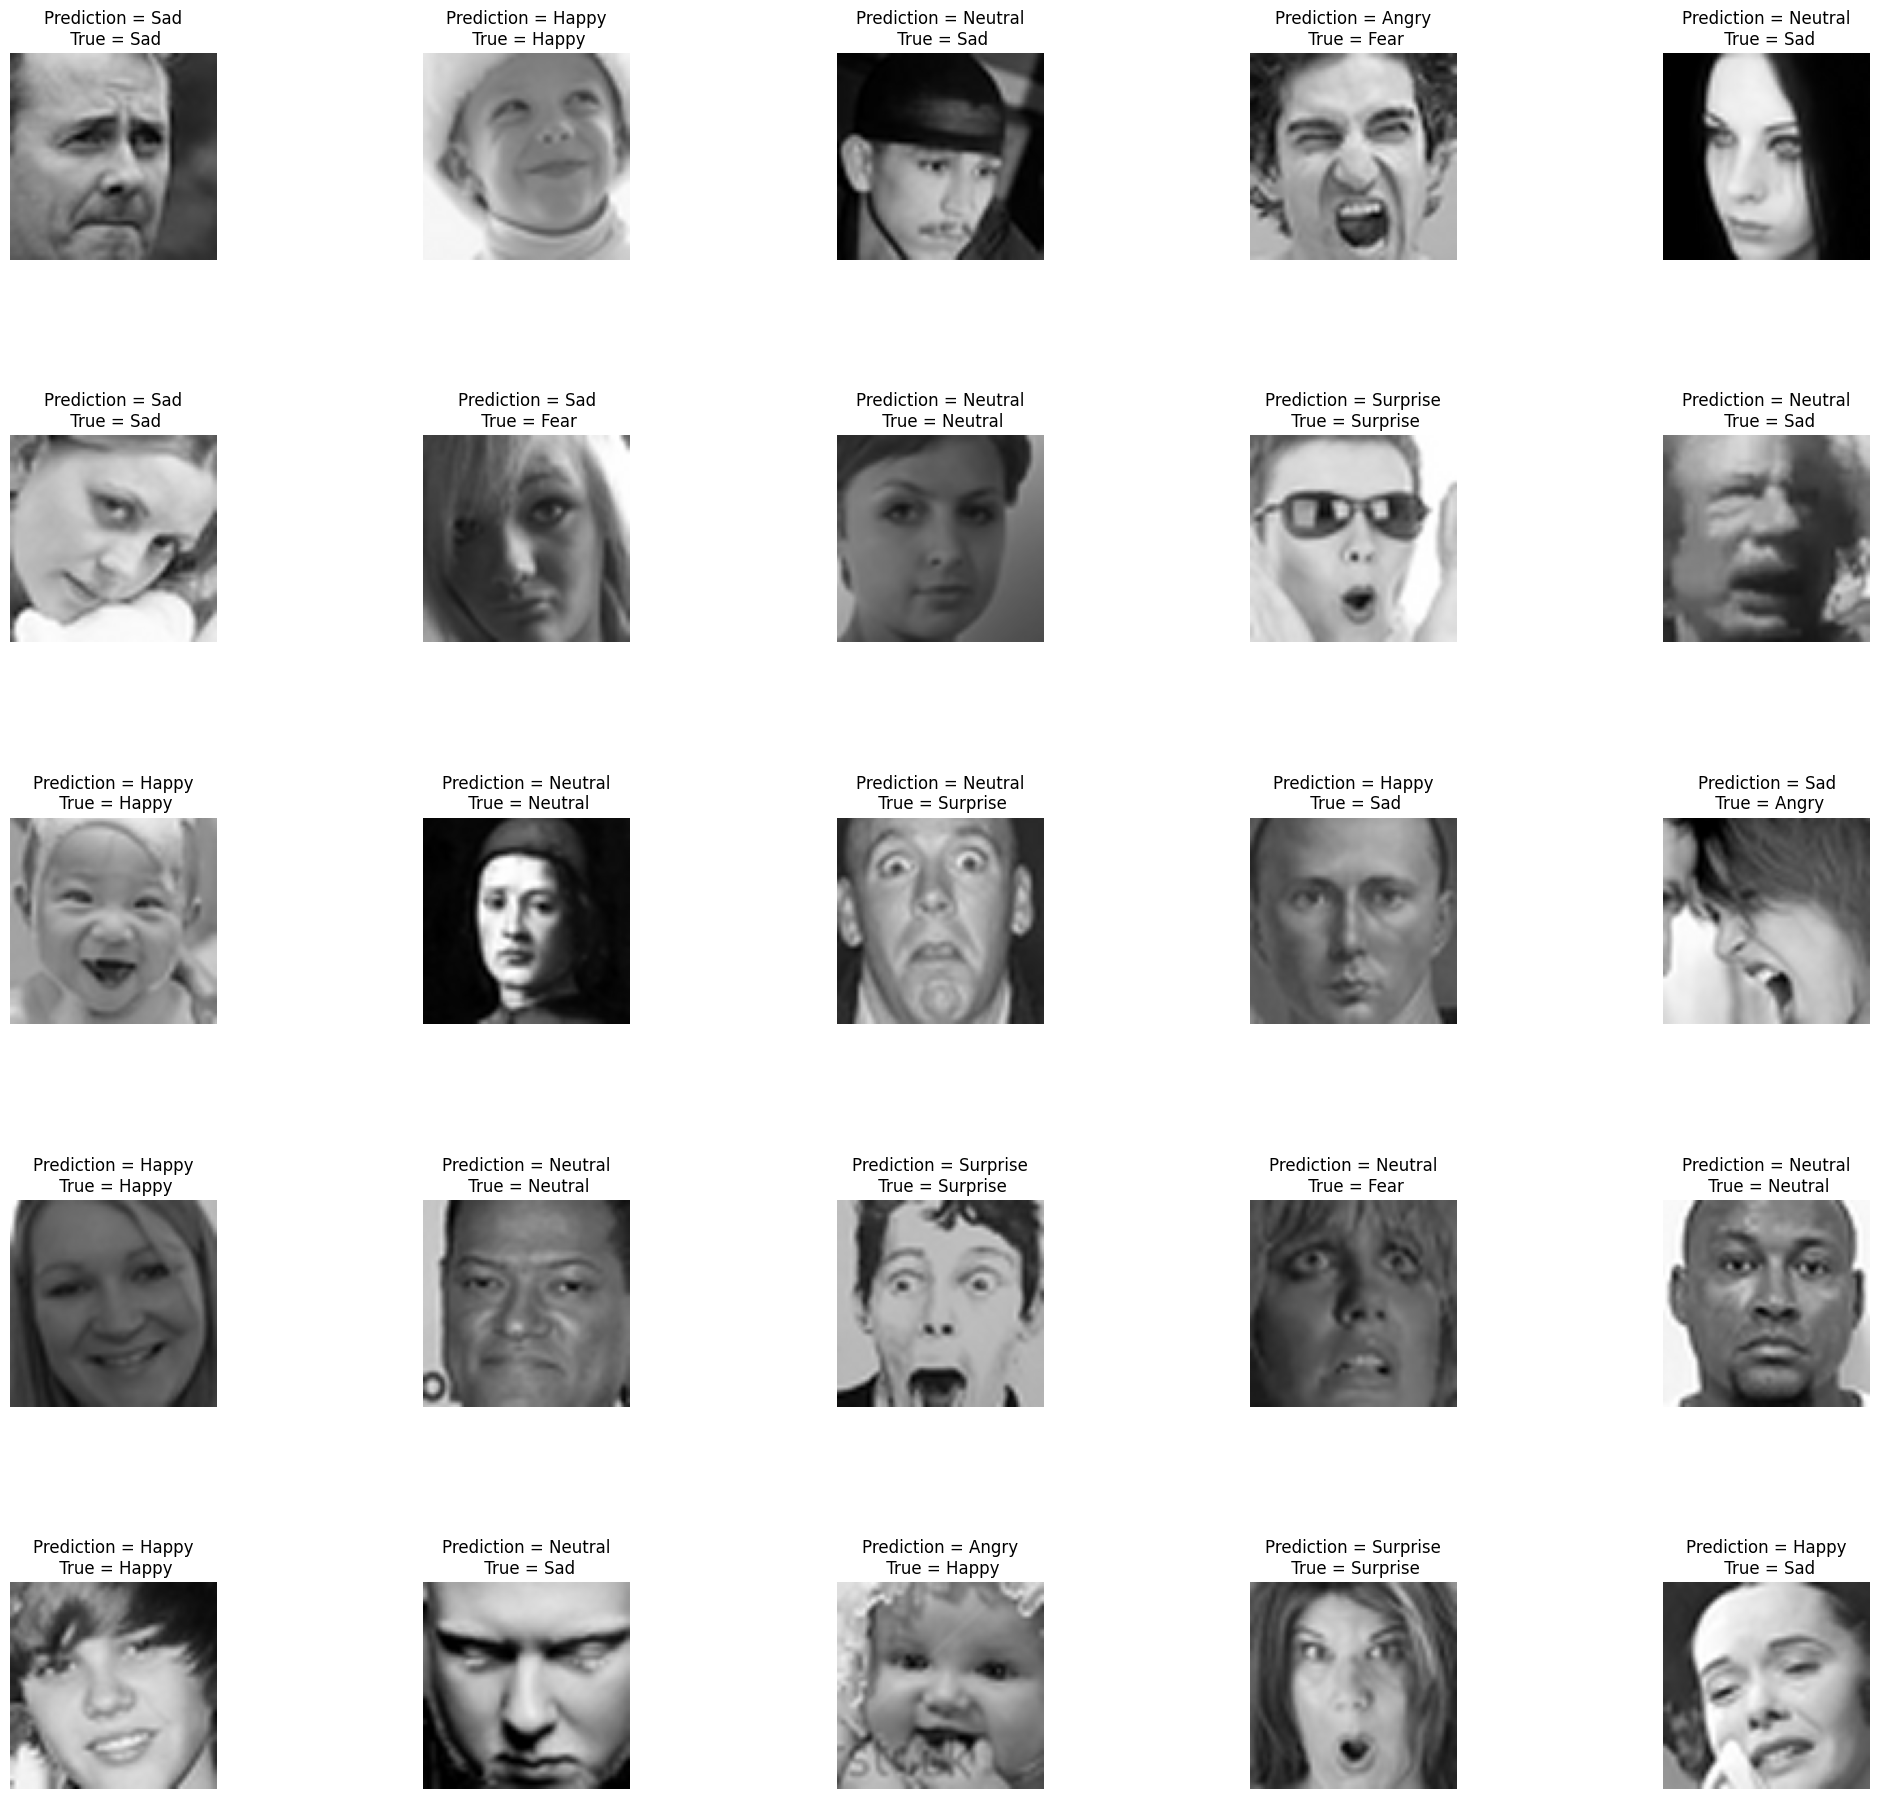

In [15]:
# Display emotion dataset images with true and predicted emotions for unseen(test) data
L, W = 5, 5
fig, axes = plt.subplots(L, W, figsize = (24, 24))
axes = axes.ravel()

for i in np.arange(0, L*W):
    axes[i].imshow(np.clip(X_Test[i].squeeze(), 0.0, 1.0),cmap='gray')
    axes[i].set_title('Prediction = {}\n True = {}'.format(emotions_dict[y_pred[i]], emotions_dict[y_true[i]]))
    axes[i].axis('off')

plt.subplots_adjust(wspace = 1)

In [73]:
# execute predict function on the test data
df_predict = predict(X_test)
df_predict.head(15)
#df_predict.shape

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,emotion
0,65.707520,38.782238,32.046906,38.565994,57.819275,40.358200,71.949310,39.836842,40.413937,40.175983,...,58.733665,63.490063,76.032890,34.744881,77.265450,49.960125,73.982925,50.160538,82.023499,3
1,63.055862,38.089905,36.661488,38.652538,56.845238,40.093941,70.813210,38.366028,44.030167,40.355507,...,62.242516,59.774288,78.891434,41.065128,78.546539,50.282265,76.629669,50.608322,86.251854,3
2,52.938526,27.838476,29.845816,28.486221,45.779785,30.076963,60.193619,28.778921,35.622540,29.527079,...,47.271019,51.587986,64.229927,30.896122,65.764114,38.516621,62.119030,36.357712,70.096359,4
3,58.053143,37.856918,34.519733,37.111866,52.366470,38.366035,61.513733,38.531036,40.087307,36.961117,...,57.197113,53.900387,74.479523,39.596863,73.948631,49.325993,70.758049,49.008682,80.420761,6
4,54.494297,33.230732,25.903353,33.617481,47.954880,33.879589,58.563774,33.410511,33.233349,33.935909,...,51.805305,51.924606,64.981400,27.867346,65.287651,40.802803,64.065392,40.786339,70.506729,3
5,74.574997,43.324459,40.972328,42.595779,67.567184,44.124149,83.934105,44.108597,50.282070,43.242275,...,68.040764,70.294167,93.993782,48.291668,94.740753,56.866734,88.890251,57.301071,104.225182,0
6,66.690216,38.674587,33.516560,39.556355,60.590576,40.215088,74.322304,39.968365,42.292824,40.560497,...,60.169220,63.575047,81.713058,38.634754,83.250763,52.440800,78.575584,50.883331,89.075546,6
7,67.777924,41.859608,36.672199,41.193989,59.683128,42.031174,76.717697,42.988754,46.481693,42.102703,...,65.776436,67.241768,86.817108,40.024841,86.255829,53.801144,83.269905,53.276752,94.022110,3
8,59.669979,36.939915,32.359985,36.835850,54.097244,37.857437,65.644409,38.186481,39.858509,36.823910,...,54.991699,56.094631,76.872955,37.822376,75.993195,46.711903,70.476120,47.423683,83.695908,6
9,58.070530,37.891323,35.543682,36.707645,53.051666,38.597275,62.269836,38.534958,41.923733,37.359989,...,58.394779,54.743153,75.642151,39.365005,74.241043,49.374168,71.109802,49.790634,81.195320,6


### Verification of Index Mapping: Predicted vs. True Keypoints

Below, for the first 5 samples from the `X_test` set displaying:

*   **`df_predict.iloc[i]`**: The predicted key facial points and emotion for the `i`-th image.
*   **`y_test[i]`**: The actual (ground truth) key facial points for the `i`-th image.

This comparison should help confirm that the rows in `df_predict` and `y_test` are indeed aligned by index to the same test images.

In [74]:
print('--- Predicted values (df_predict) ---')
display(df_predict.head(5))

print('\n--- True values (y_test) ---')
# Create a DataFrame for y_test for better readability and alignment with df_predict
y_test_df = pd.DataFrame(y_test, columns=columns)
display(y_test_df.head(5))

--- Predicted values (df_predict) ---


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,emotion
0,65.707520,38.782238,32.046906,38.565994,57.819275,40.358200,71.949310,39.836842,40.413937,40.175983,...,58.733665,63.490063,76.032890,34.744881,77.265450,49.960125,73.982925,50.160538,82.023499,3
1,63.055862,38.089905,36.661488,38.652538,56.845238,40.093941,70.813210,38.366028,44.030167,40.355507,...,62.242516,59.774288,78.891434,41.065128,78.546539,50.282265,76.629669,50.608322,86.251854,3
2,52.938526,27.838476,29.845816,28.486221,45.779785,30.076963,60.193619,28.778921,35.622540,29.527079,...,47.271019,51.587986,64.229927,30.896122,65.764114,38.516621,62.119030,36.357712,70.096359,4
3,58.053143,37.856918,34.519733,37.111866,52.366470,38.366035,61.513733,38.531036,40.087307,36.961117,...,57.197113,53.900387,74.479523,39.596863,73.948631,49.325993,70.758049,49.008682,80.420761,6
4,54.494297,33.230732,25.903353,33.617481,47.954880,33.879589,58.563774,33.410511,33.233349,33.935909,...,51.805305,51.924606,64.981400,27.867346,65.287651,40.802803,64.065392,40.786339,70.506729,3



--- True values (y_test) ---


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
0,64.875221,36.051773,28.810623,39.774220,57.807961,37.670227,72.697762,36.834026,36.848957,40.745293,...,46.946445,55.854519,66.992722,72.004257,31.852352,74.317421,49.078026,73.259270,49.225674,79.731201
1,29.945190,38.770733,65.567520,37.091206,38.426651,39.911873,20.708292,39.712288,57.186855,39.068119,...,48.716476,59.012177,30.920822,69.665047,65.054153,69.425591,48.422863,72.930359,48.401093,73.539879
2,26.249796,34.080818,61.955917,35.932243,34.757549,34.080818,19.835918,34.389389,57.746124,36.306938,...,56.848980,57.951019,35.757713,79.396301,66.799019,79.667320,52.599838,79.406097,52.995918,82.306664
3,65.658813,35.428326,30.099892,35.428326,59.861622,35.814919,70.683678,37.361298,35.124756,35.428326,...,48.265514,54.368000,57.542053,72.147888,34.738163,71.374702,46.720001,65.963242,46.720001,80.264648
4,63.667786,37.202271,30.946379,39.045731,57.215675,38.124001,72.556213,37.028755,38.436325,39.567890,...,48.305515,59.016647,67.661835,74.993187,29.390919,75.909081,48.766376,72.688866,49.688107,87.436539


### Image Visualization
Visual representation of predicted vs. True Keypoints and predicted Emotions on the test dataset.

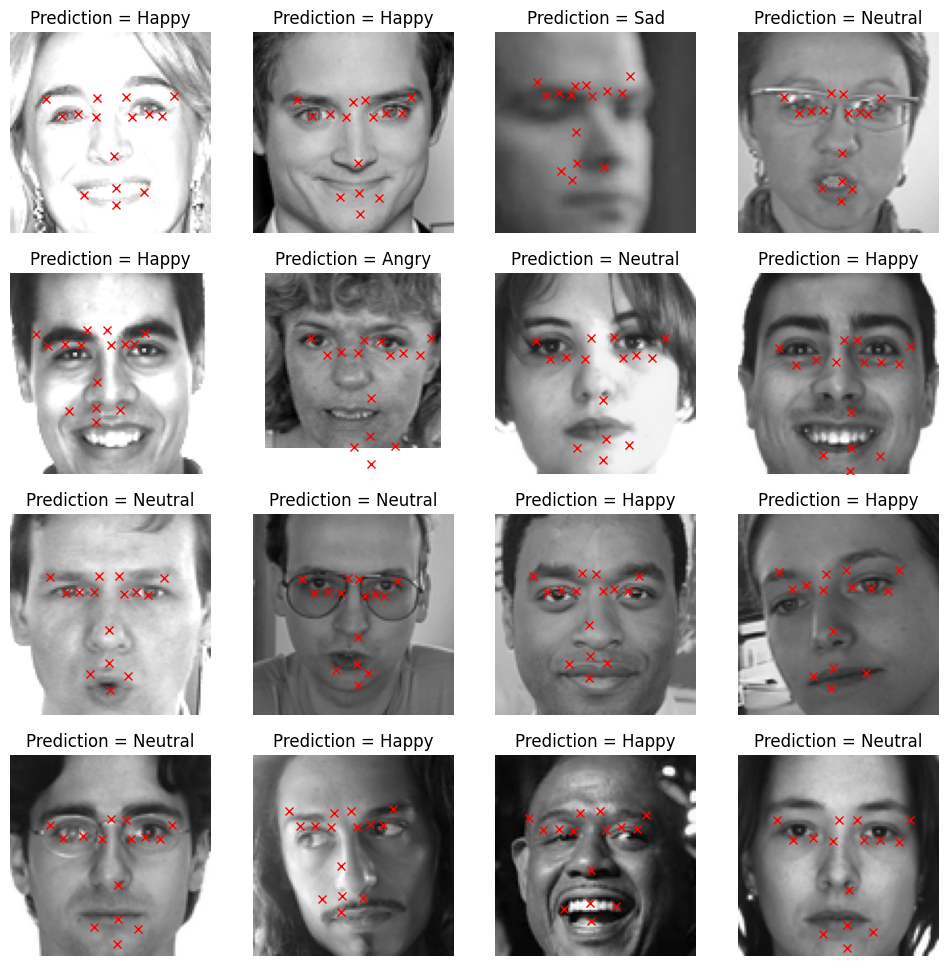

In [75]:
fig, axes = plt.subplots(4, 4, figsize = (12, 12))
axes = axes.ravel()

for i in range(16):

    axes[i].imshow(np.clip(X_test[i].squeeze(), 0.0, 1.0),cmap='gray')
    predicted_emotion_idx = df_predict['emotion'][i]
    emotion_label = emotions_dict.get(predicted_emotion_idx, f"Invalid Emotion ({predicted_emotion_idx})")
    axes[i].set_title(f'Prediction = {emotion_label}')
    axes[i].axis('off')
    #show_image_with_keypoints(i, df_predict)
    for j in range(1, 31, 2):
      axes[i].plot(df_predict.loc[i].iloc[j-1], df_predict.loc[i].iloc[j], 'rx')

A visual comparision between the predicted keypoint coordinates in `df_predict` with the true keypoint coordinates in `y_test_df` for the same index to confirm their correspondence.

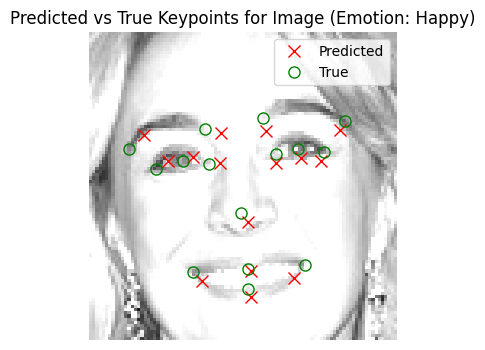

In [76]:
# image index which need to be compaired
k=0

# Get the first image from the test set
image_to_plot = X_test[k]

# Get the first row of predicted keypoints (excluding emotion)
predicted_keypoints = df_predict.iloc[k][columns]

# Get the first row of true keypoints
true_keypoints_row = y_test_df.iloc[k]

plt.figure(figsize=(4, 4))
plt.imshow(np.clip(image_to_plot.squeeze(), 0.0, 1.0), cmap='gray')

# Plot predicted keypoints
for j in range(0, len(predicted_keypoints), 2):
    plt.plot(predicted_keypoints.iloc[j], predicted_keypoints.iloc[j+1], 'rx', markersize=8, label='Predicted' if j == 0 else "")

# Plot true keypoints
for j in range(0, len(true_keypoints_row), 2):
    plt.plot(true_keypoints_row.iloc[j], true_keypoints_row.iloc[j+1], 'go', markersize=8, fillstyle='none', label='True' if j == 0 else "")

plt.title(f"Predicted vs True Keypoints for Image (Emotion: {emotions_dict.get(df_predict['emotion'].iloc[k], 'Unknown')})")
plt.legend()
plt.axis('off')
plt.show()